In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

# Load Data

In [2]:
data = pd.read_csv('/Users/vydhyamvishnusai/RANDOM_FORES_IMPLEMENTATION_BY_VISHNUSAI/Telecom_Customer_Churn (1).csv')

In [3]:
saving = data

In [4]:
data.shape

(7043, 21)

In [5]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# Data Transformation

In [7]:
data.set_index('customerID', inplace = True) 
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors = 'coerce').fillna(0).astype(int) 

In [8]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151,Yes


# Label Enconding

In [9]:
from sklearn.preprocessing import LabelEncoder 
encode = data[['gender', 'Partner', 'Dependents', 
               'PhoneService', 'MultipleLines', 'InternetService', 
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 
               'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 
               'PaymentMethod', 'Churn']] 
le = LabelEncoder() 
for i in encode:
    data[i] = le.fit_transform(data[i])

In [10]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29,0
5575-GNVDE,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889,0
3668-QPYBK,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108,1
7795-CFOCW,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840,0
9237-HQITU,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151,1


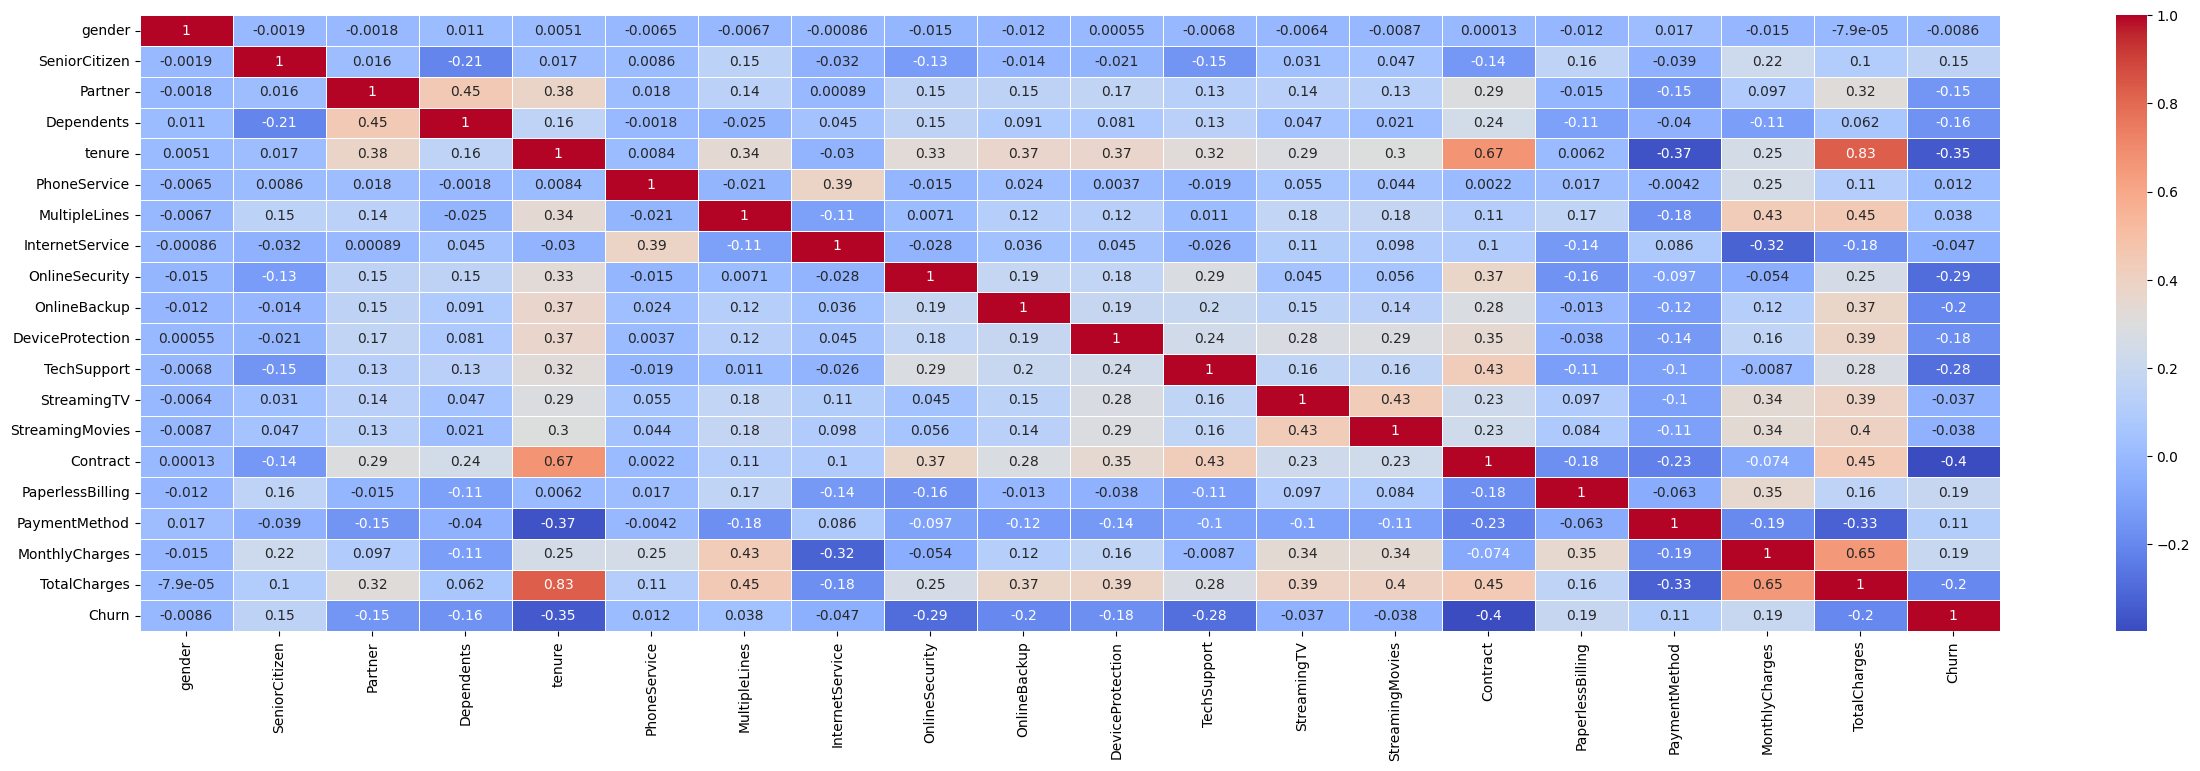

In [11]:
plt.figure(figsize = (30,8)) 
sns.heatmap(data.corr(), annot = True, linewidth = 0.5, cmap = 'coolwarm')
plt.show()

# Build Model

In [12]:
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier 
from sklearn.metrics import accuracy_score , classification_report, confusion_matrix


In [13]:
x = data.drop('Churn', axis = 1) 
y = data['Churn'] 

In [14]:
x_train, x_test, y_train , y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

In [15]:
rf = RandomForestClassifier(n_estimators = 100,criterion = "entropy", random_state = 42) 
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `met

# Model Evaluation

In [16]:
train_preds = rf.predict(x_train) 
test_preds = rf.predict(x_test)

In [17]:
training_accuracy_rf = accuracy_score(y_train, train_preds) 
test_accuracy_rf = accuracy_score(y_test, test_preds)

In [18]:
print(f"Training Accuracy: {training_accuracy_rf:.4f}") 
print(f"Testing Accuracy: {test_accuracy_rf:.4f}")

Training Accuracy: 0.9986
Testing Accuracy: 0.7970


In [19]:
from sklearn.tree import plot_tree 
import matplotlib.pyplot as plt 
single_tree = rf.estimators_[0]

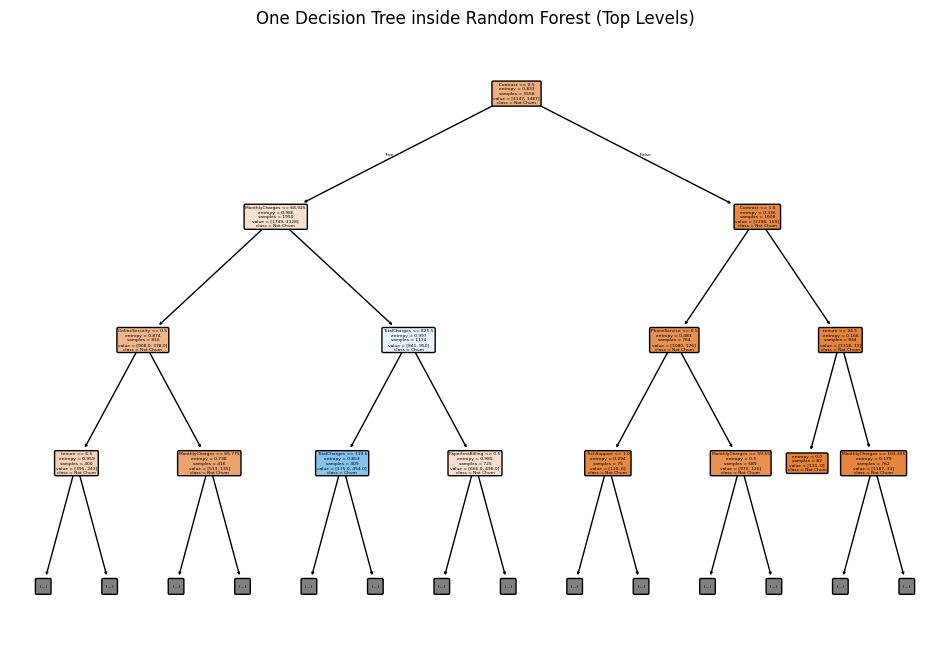

In [20]:
plt.figure(figsize = (12,8)) 
plot_tree(
    single_tree,
    feature_names = x.columns,
    class_names = ["Not Churn", "Churn"],
    max_depth = 3,
    filled = True,
    rounded = True
    
) 
plt.title("One Decision Tree inside Random Forest (Top Levels)") 
plt.show()

# Confusion Matrix

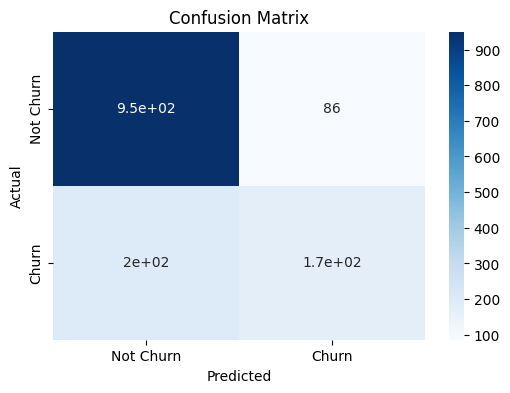

In [21]:
cm = confusion_matrix(y_test, test_preds) 
plt.figure(figsize = (6,4)) 
sns.heatmap(cm, annot = True, cmap= 'Blues', xticklabels = ["Not Churn", "Churn"], yticklabels = ["Not Churn", "Churn"]) 
plt.xlabel("Predicted") 
plt.ylabel("Actual")
plt.title("Confusion Matrix") 
plt.show()

In [22]:
print("Classification Report(Testing Data):\n") 
print(classification_report(y_test, test_preds))

Classification Report(Testing Data):

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.67      0.46      0.55       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



# AUC-ROC Curve

In [23]:
y_prob = rf.predict_proba(x_test)[:,1] 
y_prob

array([0.75, 0.15, 0.02, ..., 0.01, 0.03, 0.52], shape=(1409,))

In [24]:
from sklearn.metrics import roc_curve 
fpr, tpr, thresholds = roc_curve(y_test, y_prob) 


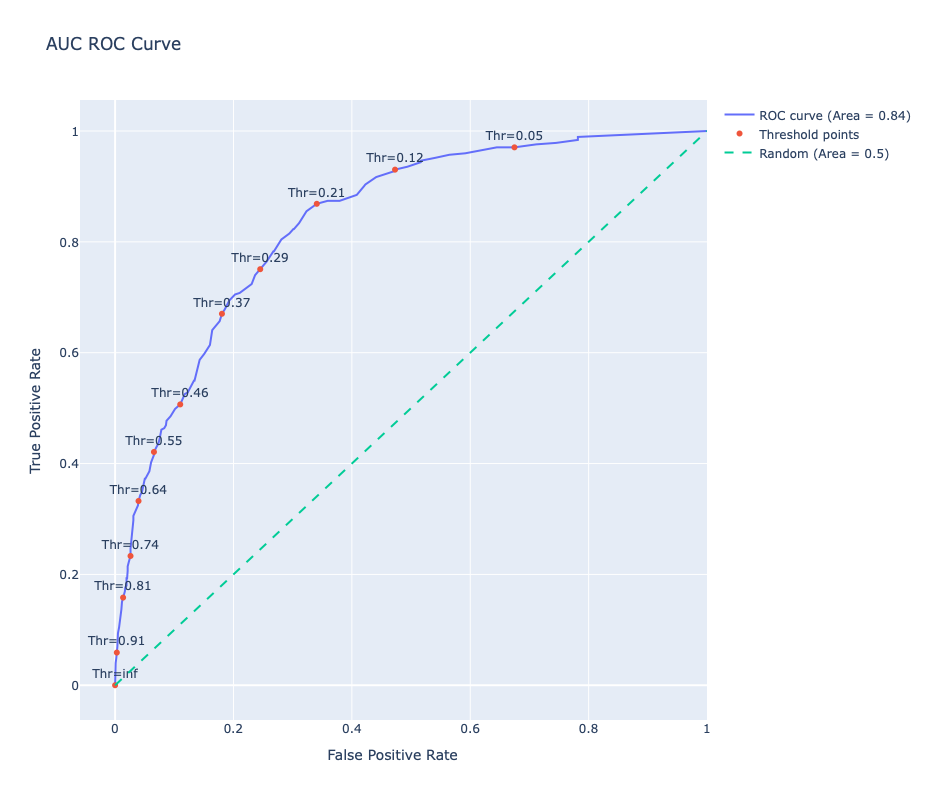

In [25]:
import plotly.graph_objects as go
import numpy as np
from sklearn.metrics import roc_auc_score
# Assuming fpr, tpr, thresholds are already calculated as before
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
# Calculate the AUC (Area Under the Curve)
roc_auc = roc_auc_score(y_test, y_prob)
# Generate a trace for ROC curve
trace0 = go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines',
    name=f'ROC curve (Area = {roc_auc:.2f})'
)
# Only label every nth point to avoid cluttering
n = 10
indices = np.arange(len(thresholds)) % n == 0  # Choose indices where index mod n is 0

trace1 = go.Scatter(
    x=fpr[indices],
    y=tpr[indices],
    mode='markers+text',
    name='Threshold points',
    text=[f"Thr={thr:.2f}" for thr in thresholds[indices]],
    textposition='top center'
)
# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)
data = [trace0, trace1, trace2]
# Define layout with square aspect ratio
layout = go.Layout(
    title='AUC ROC Curve',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=True
)
# Define figure and add data
fig = go.Figure(data=data, layout=layout)
fig.show()


# PR Curve

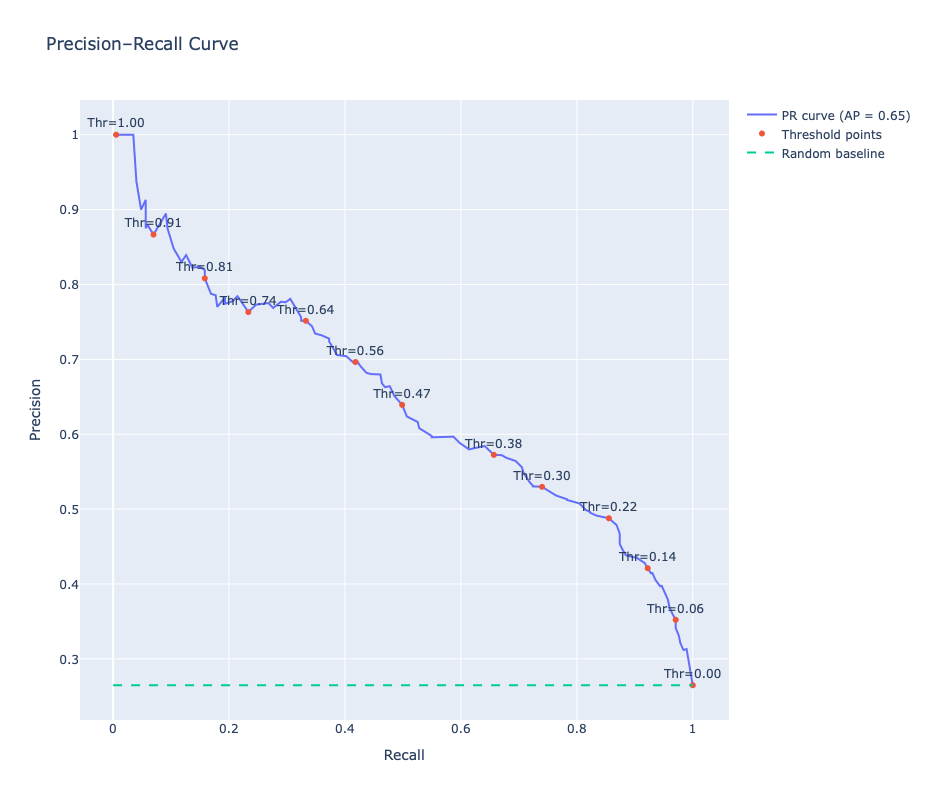

In [26]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import plotly.graph_objects as go
import numpy as np
# Compute precision, recall, thresholds
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)
# Average Precision (PR-AUC)
pr_auc = average_precision_score(y_test, y_prob)
# PR curve
trace0 = go.Scatter(
    x=recall,
    y=precision,
    mode='lines',
    name=f'PR curve (AP = {pr_auc:.2f})'
)
# Mark some threshold points (avoid clutter)
n = 10
indices = np.arange(len(pr_thresholds)) % n == 0
trace1 = go.Scatter(
    x=recall[:-1][indices],   # precision_recall_curve gives 1 extra precision value
    y=precision[:-1][indices],
    mode='markers+text',
    name='Threshold points',
    text=[f"Thr={t:.2f}" for t in pr_thresholds[indices]],
    textposition='top center'
)
# Baseline = fraction of positives (churn rate)
baseline = y_test.mean()
trace2 = go.Scatter(
    x=[0, 1],
    y=[baseline, baseline],
    mode='lines',
    name='Random baseline',
    line=dict(dash='dash')
)
# Layout
layout = go.Layout(
    title='Precision–Recall Curve',
    xaxis=dict(title='Recall'),
    yaxis=dict(title='Precision'),
    autosize=False,
    width=800,
    height=800,
    showlegend=True
)
fig_pr = go.Figure(data=[trace0, trace1, trace2], layout=layout)
fig_pr.show()


# Feature Importance : RFC

In [27]:
rf.feature_importances_

array([0.02944738, 0.02071119, 0.02420337, 0.02111963, 0.15587695,
       0.00543931, 0.02332566, 0.0263124 , 0.04351794, 0.02591364,
       0.02090778, 0.03881626, 0.01768532, 0.01853648, 0.08264612,
       0.02564275, 0.05230541, 0.19309497, 0.17449743])

In [28]:
feature_importance = pd.DataFrame({'Importance': rf.feature_importances_}, index = x.columns).sort_values('Importance')

In [29]:
feature_importance

,Importance
PhoneService,0.005439
StreamingTV,0.017685
StreamingMovies,0.018536
SeniorCitizen,0.020711
DeviceProtection,0.020908
Dependents,0.021120
MultipleLines,0.023326
Partner,0.024203
PaperlessBilling,0.025643
OnlineBackup,0.025914


Text(0.5, 1.0, 'Feature Importance')

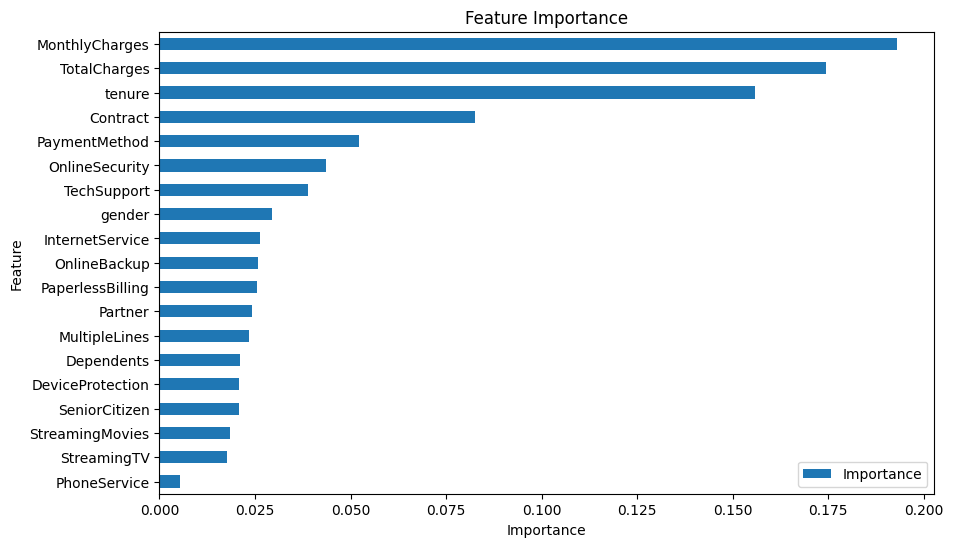

In [30]:
feature_importance.plot(y = 'Importance', kind = 'barh', figsize = (10,6)) 
plt.xlabel('Importance') 
plt.ylabel('Feature') 
plt.title('Feature Importance')

In [31]:
feature_importance[feature_importance.Importance > 0.05]

,Importance
PaymentMethod,0.052305
Contract,0.082646
tenure,0.155877
TotalCharges,0.174497
MonthlyCharges,0.193095


In [32]:
to_keep = feature_importance[feature_importance.Importance > 0.05]
to_keep

,Importance
PaymentMethod,0.052305
Contract,0.082646
tenure,0.155877
TotalCharges,0.174497
MonthlyCharges,0.193095


In [33]:
to_keep.index


Index(['PaymentMethod', 'Contract', 'tenure', 'TotalCharges',
       'MonthlyCharges'],
      dtype='str')

In [36]:
x_rf = saving[to_keep.index]
y = saving['Churn']

In [38]:
x_rf

,PaymentMethod,Contract,tenure,TotalCharges,MonthlyCharges
customerID,,,,,
7590-VHVEG,2,0,1,29,29.85
5575-GNVDE,3,1,34,1889,56.95
3668-QPYBK,3,0,2,108,53.85
7795-CFOCW,0,1,45,1840,42.30
9237-HQITU,2,0,2,151,70.70
...,...,...,...,...,...
6840-RESVB,3,1,24,1990,84.80
2234-XADUH,1,1,72,7362,103.20
4801-JZAZL,2,0,11,346,29.60


In [39]:
x_train, x_test, y_train, y_test = train_test_split(x_rf, y, test_size = 0.2, random_state = 42)

In [41]:
cls = RandomForestClassifier(n_estimators = 100, criterion = "entropy", random_state = 42)
cls.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `met

In [44]:
cls.score(x_train, y_train) 


0.9941427050053249

In [45]:
cls.score(x_test, y_test)

0.7714691270404542

In [46]:
y_pred = cls.predict(x_test) 
rfc_selected_features_accuracy = accuracy_score(y_test, y_pred) 
print(f"RFC Selected features Model Accuracy: {rfc_selected_features_accuracy}")

RFC Selected features Model Accuracy: 0.7714691270404542


# LOFO: Leave One Feature Out

In [47]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2 , random_state = 42)

In [52]:
base_accuracy = test_accuracy_rf
feature_importance_lofo = {} 
max_lofo_accuracy = base_accuracy 
for feature in x.columns:
    x_train_reduced = x_train.drop(columns = [feature]) 
    x_test_reduced = x_test.drop(columns = [feature]) 
    temp_rf = RandomForestClassifier(n_estimators = 100, criterion = 'entropy', random_state = 42 ) 
    temp_rf.fit(x_train_reduced, y_train) 
    y_pred_reduced = temp_rf.predict(x_test_reduced) 
    reduced_accuracy = accuracy_score(y_test, y_pred_reduced) 
    performance_drop = base_accuracy - reduced_accuracy 
    feature_importance_lofo[feature] = performance_drop
    if reduced_accuracy > max_lofo_accuracy:
        max_lofo_accuracy = reduced_accuracy 
sorted_importance_lofo = sorted(feature_importance_lofo.items(), key = lambda x: x[1], reverse = False) 
print("\nFeature Importance (LOFO - Performance Drop relative to full model accuracy):")
for feature, drop in sorted_importance_lofo:
    print(f"{feature}: Performance Drop = {drop:.4f}")

print(f"\nLOFO Derived Best Accuracy (by removing one feature): {max_lofo_accuracy:.4f}")
    


Feature Importance (LOFO - Performance Drop relative to full model accuracy):
Dependents: Performance Drop = -0.0035
OnlineSecurity: Performance Drop = -0.0028
gender: Performance Drop = -0.0021
PaperlessBilling: Performance Drop = -0.0007
PaymentMethod: Performance Drop = -0.0007
TechSupport: Performance Drop = 0.0014
TotalCharges: Performance Drop = 0.0014
StreamingMovies: Performance Drop = 0.0021
Partner: Performance Drop = 0.0035
PhoneService: Performance Drop = 0.0035
OnlineBackup: Performance Drop = 0.0035
DeviceProtection: Performance Drop = 0.0035
InternetService: Performance Drop = 0.0043
SeniorCitizen: Performance Drop = 0.0050
tenure: Performance Drop = 0.0050
Contract: Performance Drop = 0.0050
StreamingTV: Performance Drop = 0.0064
MultipleLines: Performance Drop = 0.0078
MonthlyCharges: Performance Drop = 0.0078

LOFO Derived Best Accuracy (by removing one feature): 0.8006


In [55]:
accuracy_scores = {
    'Base Model Accuracy': test_accuracy_rf, 
    'RFC Selected Features Model Accuracy': rfc_selected_features_accuracy, 
    'LOFO Derived Best Accuracy': max_lofo_accuracy
}
print("Collected Accuracy Scores:") 
for model, score in accuracy_scores.items():
    print(f"- {model}: {score:.4f}")

Collected Accuracy Scores:
- Base Model Accuracy: 0.7970
- RFC Selected Features Model Accuracy: 0.7715
- LOFO Derived Best Accuracy: 0.8006
